# 4주차 추가 실험

**기준**: `Membership_features_clean.csv` (다중공선성 제거 후 74개)

| 모델 | 변수 | 목적 |
|------|------|------|
| Model A | 기존 74개 | 현재 모델 Train/Test 확인 |
| Model B | 74개 + 4주차 변수 | 4주차 추가 시 성능 변화 + 과적합 여부 |

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score
import xgboost as xgb

BASE = Path('..').resolve()
SEED = 42

# 기존 다중공선성 제거 완료 데이터 (74개)
df = pd.read_csv(BASE / '_data/02_interim/260510_features/Membership_features_clean.csv', encoding='utf-8-sig')
print(f'기존 clean 데이터: {df.shape}')
df.head(3)

기존 clean 데이터: (23343, 81)


,USER_KEY,product_code,price,billing_method,is_churn_prevented,payment_device,is_user_verified,gender,age,is_repurchase,...,family_ratio,drama_ratio,action_ratio,thriller_ratio,sf_ratio,comedy_ratio,romance_ratio,action_sf_thriller_affinity,family_content_affinity,genre_entropy_norm
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,0,pc,1,F,20.0,1,...,0.0769,0.2308,0.3077,0.2308,0.0,0.0,0.0769,1.0,0.0,0.9105
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,pc,1,F,25.0,0,...,0.0000,0.3333,0.6667,0.0000,0.0,0.0,0.0000,1.0,0.0,0.9183
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,0,android,1,F,20.0,0,...,0.0000,0.0000,0.0000,0.5000,0.0,0.5,0.0000,1.0,0.0,1.0000


## 4주차 변수 생성 (View_History에서 21~27일 데이터 추출)

In [3]:
# View_History + 날짜 매핑
mem  = pd.read_csv(BASE / '_data/02_interim/260510_merged_v2/Membership_v2.csv',   encoding='utf-8-sig')
vh   = pd.read_csv(BASE / '_data/02_interim/260510_merged_v2/View_History_v2.csv', encoding='utf-8-sig')
umap = pd.read_csv(BASE / '_data/02_interim/260510_merged_v2/User_Mapping_v2.csv', encoding='utf-8-sig')

def decode_date(s):
    parts = str(s).split('-')
    return pd.Timestamp(year=2000+int(parts[2]), month=int(parts[1]), day=int(parts[0][2:]))

mem['reg_date_dt'] = mem['reg_date'].apply(decode_date)

vh['watch_date'] = pd.to_datetime(vh['watch_day'].astype(str))
vh = vh.merge(umap, on='USER_NUM', how='left')
vh = vh.merge(mem[['USER_KEY','reg_date_dt']], on='USER_KEY', how='left')
vh['obs_day'] = (vh['watch_date'] - vh['reg_date_dt']).dt.days

# 4주차 필터 (21~27일)
vh_w4 = vh[(vh['obs_day'] >= 21) & (vh['obs_day'] < 28)]
print(f'4주차 로그 수: {len(vh_w4):,}건')
print(f'4주차 로그 있는 유저: {vh_w4["USER_KEY"].nunique():,}명')

4주차 로그 수: 15,885건
4주차 로그 있는 유저: 5,754명


In [4]:
# 4주차 변수 생성
w4_feat = vh_w4.groupby('USER_KEY').agg(
    dur_w4           = ('watch_time(min)', 'sum'),
    week4_sessions   = ('watch_time(min)', 'count'),
    week4_active     = ('watch_day', 'nunique'),
).reset_index()

w4_feat['retention_w4']       = 1
w4_feat['retention_w4_ratio'] = w4_feat['week4_active'] / 7

# 기존 데이터에 merge
df_4w = df.merge(w4_feat[['USER_KEY','dur_w4','retention_w4','retention_w4_ratio','week4_sessions','week4_active']],
                 on='USER_KEY', how='left')

# 4주차 없는 유저 = 0
for col in ['dur_w4','retention_w4','retention_w4_ratio','week4_sessions','week4_active']:
    df_4w[col] = df_4w[col].fillna(0)

# w4_minus_w3 트렌드
df_4w['w4_minus_w3'] = df_4w['dur_w4'] - df_4w['dur_w3']

print(f'4주차 추가 후 shape: {df_4w.shape}')
print(f'\ndur_w4 통계:')
print(df_4w['dur_w4'].describe())
print(f'\n이탈자 중 dur_w4=0: {df_4w[df_4w["is_repurchase"]==0]["dur_w4"].eq(0).mean():.1%}')
print(f'재구매자 중 dur_w4=0: {df_4w[df_4w["is_repurchase"]==1]["dur_w4"].eq(0).mean():.1%}')

4주차 추가 후 shape: (23343, 87)

dur_w4 통계:
count    23343.000000
mean        31.949835
std        112.856502
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3449.000000
Name: dur_w4, dtype: float64

이탈자 중 dur_w4=0: 87.6%
재구매자 중 dur_w4=0: 70.0%


## 모델 학습 함수 (Train/Test 둘 다 평가)

In [5]:
EXCLUDE = ['USER_KEY','product_code','payment_device','device_group',
           'gender','age_group','is_repurchase']

def train_evaluate(df, label):
    df_ = df.copy()
    for col in df_.select_dtypes('object').columns:
        if col not in EXCLUDE:
            df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))

    FEAT = [c for c in df_.columns if c not in EXCLUDE]
    X = df_[FEAT].fillna(0)
    y = df_['is_repurchase']

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    spw = (y_tr==0).sum() / (y_tr==1).sum()

    model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    # Train 평가
    tr_proba = model.predict_proba(X_tr)[:,1]
    tr_pred  = model.predict(X_tr)
    train_auc = roc_auc_score(y_tr, tr_proba)
    train_f1  = f1_score(y_tr, tr_pred)

    # Test 평가
    te_proba = model.predict_proba(X_te)[:,1]
    te_pred  = model.predict(X_te)
    test_auc = roc_auc_score(y_te, te_proba)
    test_f1  = f1_score(y_te, te_pred)

    gap = train_auc - test_auc
    judge = '🔴 과적합 의심' if gap > 0.03 else ('🟡 주의' if gap > 0.01 else '🟢 정상')

    print(f'[{label}]  변수: {len(FEAT)}개  |  best_iter: {model.best_iteration}')
    print(f'  Train  →  AUC: {train_auc:.4f}  F1: {train_f1:.4f}')
    print(f'  Test   →  AUC: {test_auc:.4f}  F1: {test_f1:.4f}')
    print(f'  Gap(Train-Test AUC): {gap:.4f}  {judge}')
    print()

    return {
        '모델': label, '변수 수': len(FEAT),
        'Train AUC': round(train_auc,4), 'Test AUC': round(test_auc,4),
        'Train F1':  round(train_f1,4),  'Test F1':  round(test_f1,4),
        'Gap': round(gap,4), '판정': judge,
        'Best iter': model.best_iteration
    }

In [6]:
r_3w = train_evaluate(df,    'Model A: 3주차 (74개)')
r_4w = train_evaluate(df_4w, 'Model B: 4주차 추가 (74+6개)')

[Model A: 3주차 (74개)]  변수: 74개  |  best_iter: 483
  Train  →  AUC: 0.9768  F1: 0.9298
  Test   →  AUC: 0.8826  F1: 0.8582
  Gap(Train-Test AUC): 0.0942  🔴 과적합 의심

[Model B: 4주차 추가 (74+6개)]  변수: 80개  |  best_iter: 494
  Train  →  AUC: 0.9817  F1: 0.9478
  Test   →  AUC: 0.9053  F1: 0.8799
  Gap(Train-Test AUC): 0.0764  🔴 과적합 의심



## 결과 비교

In [7]:
cmp = pd.DataFrame([r_3w, r_4w])
print('=== 최종 비교 ===')
print(cmp.to_string(index=False))

diff_auc = r_4w['Test AUC'] - r_3w['Test AUC']
diff_f1  = r_4w['Test F1']  - r_3w['Test F1']
print(f'\n4주차 추가 효과 (Test 기준):')
print(f'  AUC: {diff_auc:+.4f}')
print(f'  F1:  {diff_f1:+.4f}')

if r_4w['Gap'] > 0.03:
    print('\n⚠️  4주차 모델 과적합 의심 — 운영 모델로 부적합')
elif diff_auc > 0.01:
    print('\n✅  4주차 추가 시 유의미한 성능 향상 + 과적합 없음')
else:
    print('\nℹ️  4주차 추가 효과 미미 — 3주차 모델 유지 권장')

=== 최종 비교 ===
                     모델  변수 수  Train AUC  Test AUC  Train F1  Test F1    Gap       판정  Best iter
     Model A: 3주차 (74개)    74     0.9768    0.8826    0.9298   0.8582 0.0942 🔴 과적합 의심        483
Model B: 4주차 추가 (74+6개)    80     0.9817    0.9053    0.9478   0.8799 0.0764 🔴 과적합 의심        494

4주차 추가 효과 (Test 기준):
  AUC: +0.0227
  F1:  +0.0217

⚠️  4주차 모델 과적합 의심 — 운영 모델로 부적합


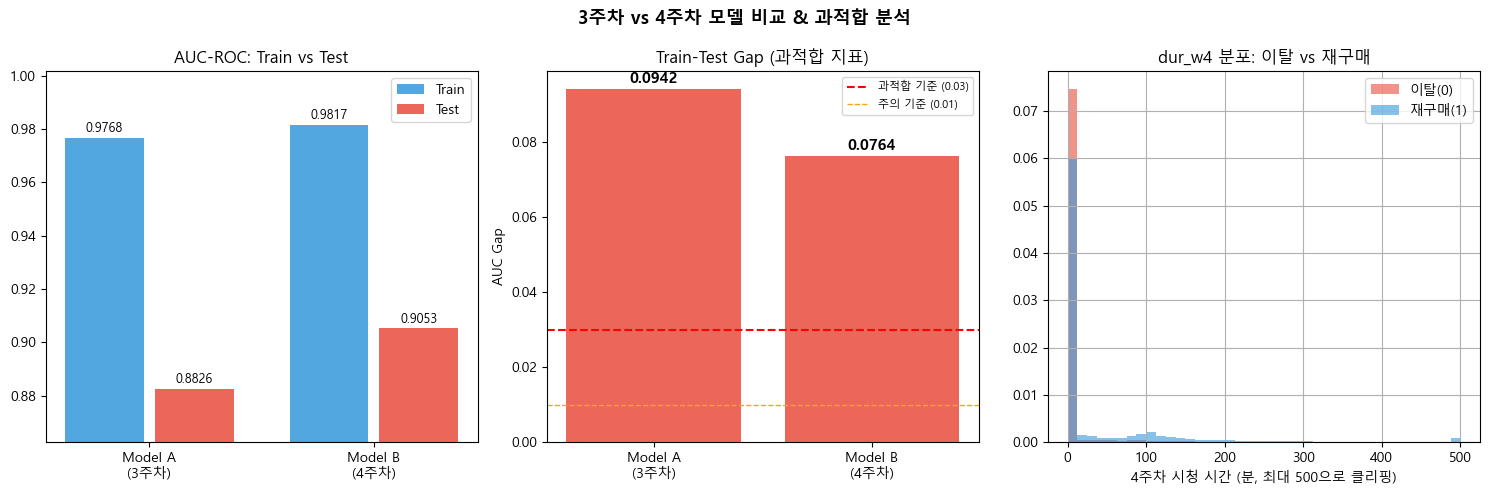

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ① AUC Train vs Test
ax = axes[0]
labels = ['Model A\n(3주차)', 'Model B\n(4주차)']
tr_aucs = [r_3w['Train AUC'], r_4w['Train AUC']]
te_aucs = [r_3w['Test AUC'],  r_4w['Test AUC']]
x = np.arange(2)
ax.bar(x-0.2, tr_aucs, 0.35, label='Train', color='#3498db', alpha=0.85)
ax.bar(x+0.2, te_aucs, 0.35, label='Test',  color='#e74c3c', alpha=0.85)
for i,(tr,te) in enumerate(zip(tr_aucs,te_aucs)):
    ax.text(i-0.2, tr+0.001, f'{tr:.4f}', ha='center', va='bottom', fontsize=9)
    ax.text(i+0.2, te+0.001, f'{te:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('AUC-ROC: Train vs Test')
ax.set_ylim(max(0.8, min(tr_aucs+te_aucs)-0.02), max(tr_aucs+te_aucs)+0.02)
ax.legend()

# ② Gap (과적합 지표)
ax = axes[1]
gaps = [r_3w['Gap'], r_4w['Gap']]
colors = ['#2ecc71' if g<=0.01 else ('#f39c12' if g<=0.03 else '#e74c3c') for g in gaps]
bars = ax.bar(labels, gaps, color=colors, alpha=0.85)
ax.axhline(0.03, color='red',    linestyle='--', linewidth=1.5, label='과적합 기준 (0.03)')
ax.axhline(0.01, color='orange', linestyle='--', linewidth=1,   label='주의 기준 (0.01)')
for bar, g in zip(bars, gaps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
            f'{g:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Train-Test Gap (과적합 지표)')
ax.set_ylabel('AUC Gap')
ax.legend(fontsize=8)

# ③ dur_w4 분포: 이탈 vs 재구매
ax = axes[2]
df_4w[df_4w['is_repurchase']==0]['dur_w4'].clip(upper=500).hist(
    bins=40, ax=ax, alpha=0.6, color='#e74c3c', label='이탈(0)', density=True)
df_4w[df_4w['is_repurchase']==1]['dur_w4'].clip(upper=500).hist(
    bins=40, ax=ax, alpha=0.6, color='#3498db', label='재구매(1)', density=True)
ax.set_title('dur_w4 분포: 이탈 vs 재구매')
ax.set_xlabel('4주차 시청 시간 (분, 최대 500으로 클리핑)')
ax.legend()

plt.suptitle('3주차 vs 4주차 모델 비교 & 과적합 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 해석 기준

| Gap | 판정 | 조치 |
|-----|------|------|
| < 0.01 | 🟢 정상 | 4주차 사용 가능 |
| 0.01~0.03 | 🟡 주의 | 검토 후 결정 |
| > 0.03 | 🔴 과적합 | 4주차 사용 불가 |

**dur_w4 분포에서 이탈/재구매가 완전히 분리되면** → 누수 가능성 높음 (타겟이 변수에 새어 들어온 것)

## 정규화 강화 모델 (과적합 완화 시도)

Gap이 큰 원인: `dur_w3` 같은 강력한 변수에 모델이 과도하게 의존
→ max_depth 줄이고 L1/L2 정규화 추가해서 Gap 변화 확인

In [9]:
def train_evaluate_reg(df, label):
    """정규화 강화 버전 (max_depth↓, alpha↑, lambda↑)"""
    df_ = df.copy()
    for col in df_.select_dtypes('object').columns:
        if col not in EXCLUDE:
            df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))

    FEAT = [c for c in df_.columns if c not in EXCLUDE]
    X = df_[FEAT].fillna(0)
    y = df_['is_repurchase']

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    spw = (y_tr==0).sum() / (y_tr==1).sum()

    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,   # 0.05 → 0.03
        max_depth=4,          # 6 → 4 (깊이 줄임)
        reg_alpha=1.0,        # L1 정규화 추가
        reg_lambda=2.0,       # L2 정규화 강화
        scale_pos_weight=spw,
        subsample=0.7,        # 0.8 → 0.7
        colsample_bytree=0.7, # 0.8 → 0.7
        eval_metric='logloss', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    tr_proba = model.predict_proba(X_tr)[:,1]
    te_proba = model.predict_proba(X_te)[:,1]
    tr_pred  = model.predict(X_tr)
    te_pred  = model.predict(X_te)

    train_auc = roc_auc_score(y_tr, tr_proba)
    test_auc  = roc_auc_score(y_te, te_proba)
    train_f1  = f1_score(y_tr, tr_pred)
    test_f1   = f1_score(y_te, te_pred)
    gap = train_auc - test_auc
    judge = '🔴 과적합 의심' if gap > 0.03 else ('🟡 주의' if gap > 0.01 else '🟢 정상')

    print(f'[{label}]  변수: {len(FEAT)}개  |  best_iter: {model.best_iteration}')
    print(f'  Train  →  AUC: {train_auc:.4f}  F1: {train_f1:.4f}')
    print(f'  Test   →  AUC: {test_auc:.4f}  F1: {test_f1:.4f}')
    print(f'  Gap(Train-Test AUC): {gap:.4f}  {judge}')
    print()

    return {
        '모델': label, '변수 수': len(FEAT),
        'Train AUC': round(train_auc,4), 'Test AUC': round(test_auc,4),
        'Train F1':  round(train_f1,4),  'Test F1':  round(test_f1,4),
        'Gap': round(gap,4), '판정': judge,
        'Best iter': model.best_iteration
    }

r_3w_reg = train_evaluate_reg(df,    'Model C: 3주차 + 정규화')
r_4w_reg = train_evaluate_reg(df_4w, 'Model D: 4주차 + 정규화')

[Model C: 3주차 + 정규화]  변수: 74개  |  best_iter: 499
  Train  →  AUC: 0.9099  F1: 0.8635
  Test   →  AUC: 0.8860  F1: 0.8463
  Gap(Train-Test AUC): 0.0240  🟡 주의

[Model D: 4주차 + 정규화]  변수: 80개  |  best_iter: 499
  Train  →  AUC: 0.9283  F1: 0.8921
  Test   →  AUC: 0.9080  F1: 0.8757
  Gap(Train-Test AUC): 0.0203  🟡 주의



=== 4개 모델 최종 비교 ===
                     모델  변수 수  Train AUC  Test AUC    Gap       판정  Test F1
     Model A: 3주차 (74개)    74     0.9768    0.8826 0.0942 🔴 과적합 의심   0.8582
Model B: 4주차 추가 (74+6개)    80     0.9817    0.9053 0.0764 🔴 과적합 의심   0.8799
     Model C: 3주차 + 정규화    74     0.9099    0.8860 0.0240     🟡 주의   0.8463
     Model D: 4주차 + 정규화    80     0.9283    0.9080 0.0203     🟡 주의   0.8757


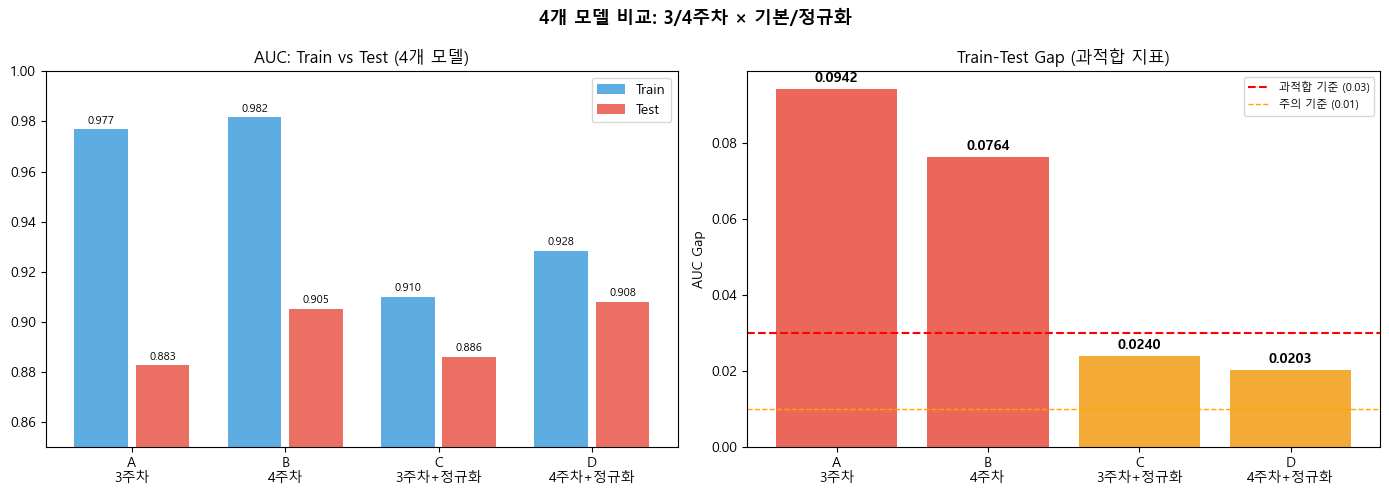


✅ Test AUC 최고 모델: Model D: 4주차 + 정규화 (0.9080)
✅ Gap 최소 모델:      Model D: 4주차 + 정규화 (Gap=0.0203)


In [10]:
# 4개 모델 최종 비교
all_results = pd.DataFrame([r_3w, r_4w, r_3w_reg, r_4w_reg])
print('=== 4개 모델 최종 비교 ===')
print(all_results[['모델','변수 수','Train AUC','Test AUC','Gap','판정','Test F1']].to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_label = ['A\n3주차', 'B\n4주차', 'C\n3주차+정규화', 'D\n4주차+정규화']
tr_aucs = all_results['Train AUC'].tolist()
te_aucs = all_results['Test AUC'].tolist()
gaps    = all_results['Gap'].tolist()
x = np.arange(4)

# AUC 비교
ax = axes[0]
ax.bar(x-0.2, tr_aucs, 0.35, label='Train', color='#3498db', alpha=0.8)
ax.bar(x+0.2, te_aucs, 0.35, label='Test',  color='#e74c3c', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(models_label)
ax.set_title('AUC: Train vs Test (4개 모델)')
ax.set_ylim(0.85, 1.0)
ax.legend()
for i,(tr,te) in enumerate(zip(tr_aucs, te_aucs)):
    ax.text(i-0.2, tr+0.001, f'{tr:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i+0.2, te+0.001, f'{te:.3f}', ha='center', va='bottom', fontsize=8)

# Gap 비교
ax = axes[1]
colors = ['#e74c3c' if g>0.03 else ('#f39c12' if g>0.01 else '#2ecc71') for g in gaps]
bars = ax.bar(models_label, gaps, color=colors, alpha=0.85)
ax.axhline(0.03, color='red',    linestyle='--', linewidth=1.5, label='과적합 기준 (0.03)')
ax.axhline(0.01, color='orange', linestyle='--', linewidth=1,   label='주의 기준 (0.01)')
for bar, g in zip(bars, gaps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{g:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Train-Test Gap (과적합 지표)')
ax.set_ylabel('AUC Gap')
ax.legend(fontsize=8)

plt.suptitle('4개 모델 비교: 3/4주차 × 기본/정규화', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 결론
best_test = all_results.loc[all_results['Test AUC'].idxmax()]
print(f'\n✅ Test AUC 최고 모델: {best_test["모델"]} ({best_test["Test AUC"]:.4f})')
best_gap  = all_results.loc[all_results['Gap'].idxmin()]
print(f'✅ Gap 최소 모델:      {best_gap["모델"]} (Gap={best_gap["Gap"]:.4f})')

## K-Fold 교차검증 (5-Fold)

현재 80:20 단일 분할 → 운에 따라 결과가 달라질 수 있음  
5-Fold로 나눠서 평균 Test AUC가 얼마나 안정적인지 확인

In [11]:
from sklearn.model_selection import StratifiedKFold

def kfold_evaluate(df, label, k=5):
    df_ = df.copy()
    for col in df_.select_dtypes('object').columns:
        if col not in EXCLUDE:
            df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))

    FEAT = [c for c in df_.columns if c not in EXCLUDE]
    X = df_[FEAT].fillna(0).values
    y = df_['is_repurchase'].values

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    spw = (y==0).sum() / (y==1).sum()

    fold_train_aucs, fold_test_aucs, fold_gaps = [], [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', early_stopping_rounds=50,
            random_state=SEED, n_jobs=-1, verbosity=0
        )
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

        tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:,1])
        te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
        gap    = tr_auc - te_auc

        fold_train_aucs.append(tr_auc)
        fold_test_aucs.append(te_auc)
        fold_gaps.append(gap)
        print(f'  Fold {fold}: Train={tr_auc:.4f}  Test={te_auc:.4f}  Gap={gap:.4f}')

    print(f'\n[{label}] {k}-Fold 결과 요약')
    print(f'  Train AUC: {np.mean(fold_train_aucs):.4f} ± {np.std(fold_train_aucs):.4f}')
    print(f'  Test  AUC: {np.mean(fold_test_aucs):.4f} ± {np.std(fold_test_aucs):.4f}')
    print(f'  Gap   평균: {np.mean(fold_gaps):.4f} ± {np.std(fold_gaps):.4f}')
    judge = '🔴 과적합' if np.mean(fold_gaps) > 0.03 else ('🟡 주의' if np.mean(fold_gaps) > 0.01 else '🟢 정상')
    print(f'  판정: {judge}')

    return {
        '모델': label,
        'Train AUC (평균)': round(np.mean(fold_train_aucs), 4),
        'Train AUC (std)':  round(np.std(fold_train_aucs), 4),
        'Test AUC (평균)':  round(np.mean(fold_test_aucs), 4),
        'Test AUC (std)':   round(np.std(fold_test_aucs), 4),
        'Gap (평균)':        round(np.mean(fold_gaps), 4),
        '판정': judge,
        'fold_test_aucs': fold_test_aucs
    }

print('=== 3주차 5-Fold ===')
kf_3w = kfold_evaluate(df,    '3주차 (74개)')
print()
print('=== 4주차 5-Fold ===')
kf_4w = kfold_evaluate(df_4w, '4주차 (80개)')

=== 3주차 5-Fold ===
  Fold 1: Train=0.9767  Test=0.8735  Gap=0.1032
  Fold 2: Train=0.9774  Test=0.8794  Gap=0.0980
  Fold 3: Train=0.9779  Test=0.8769  Gap=0.1010
  Fold 4: Train=0.9771  Test=0.8800  Gap=0.0971
  Fold 5: Train=0.9779  Test=0.8756  Gap=0.1023

[3주차 (74개)] 5-Fold 결과 요약
  Train AUC: 0.9774 ± 0.0005
  Test  AUC: 0.8771 ± 0.0024
  Gap   평균: 0.1003 ± 0.0024
  판정: 🔴 과적합

=== 4주차 5-Fold ===
  Fold 1: Train=0.9784  Test=0.9005  Gap=0.0780
  Fold 2: Train=0.9813  Test=0.9018  Gap=0.0795
  Fold 3: Train=0.9792  Test=0.9033  Gap=0.0759
  Fold 4: Train=0.9803  Test=0.9040  Gap=0.0763
  Fold 5: Train=0.9812  Test=0.8980  Gap=0.0832

[4주차 (80개)] 5-Fold 결과 요약
  Train AUC: 0.9801 ± 0.0011
  Test  AUC: 0.9015 ± 0.0021
  Gap   평균: 0.0786 ± 0.0026
  판정: 🔴 과적합


## 변수별 누수 탐지 (단일 변수 AUC 테스트)

**방법**: 변수 하나만으로 타겟(is_repurchase) 예측 → AUC가 0.75 이상이면 누수 의심

| AUC | 판정 |
|-----|------|
| > 0.80 | 🔴 누수 강의심 |
| 0.75~0.80 | 🟡 누수 주의 |
| < 0.75 | 🟢 정상 |

In [12]:
from sklearn.metrics import roc_auc_score
import scipy.stats as stats

df_ = df.copy()
for col in df_.select_dtypes('object').columns:
    if col not in EXCLUDE:
        df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))

FEAT = [c for c in df_.columns if c not in EXCLUDE]
y = df_['is_repurchase']

leak_results = []
for feat in FEAT:
    x = df_[feat].fillna(0)
    # 단일 변수 AUC (상관 방향 무관하게 max(auc, 1-auc))
    try:
        auc = roc_auc_score(y, x)
        auc = max(auc, 1 - auc)  # 음의 상관도 탐지
    except:
        auc = 0.5

    # 피어슨 상관계수
    corr, pval = stats.pearsonr(x, y)

    if auc >= 0.80:
        judge = '🔴 누수 강의심'
    elif auc >= 0.75:
        judge = '🟡 누수 주의'
    else:
        judge = '🟢 정상'

    leak_results.append({
        '변수': feat,
        '단일 AUC': round(auc, 4),
        '상관계수': round(corr, 4),
        '판정': judge
    })

leak_df = pd.DataFrame(leak_results).sort_values('단일 AUC', ascending=False).reset_index(drop=True)
leak_df.index += 1

print('=== 단일 변수 AUC 누수 탐지 ===')
print(f'🔴 누수 강의심 (AUC≥0.80): {(leak_df["단일 AUC"]>=0.80).sum()}개')
print(f'🟡 누수 주의  (0.75~0.80): {((leak_df["단일 AUC"]>=0.75)&(leak_df["단일 AUC"]<0.80)).sum()}개')
print(f'🟢 정상       (AUC<0.75):  {(leak_df["단일 AUC"]<0.75).sum()}개')
print()
print('[ 상위 30개 ]')
print(leak_df.head(30).to_string())

=== 단일 변수 AUC 누수 탐지 ===
🔴 누수 강의심 (AUC≥0.80): 0개
🟡 누수 주의  (0.75~0.80): 0개
🟢 정상       (AUC<0.75):  74개

[ 상위 30개 ]
                            변수  단일 AUC    상관계수    판정
1                       dur_w3  0.7169  0.2669  🟢 정상
2                      recency  0.6796 -0.2863  🟢 정상
3           retention_w3_ratio  0.6690  0.1333  🟢 정상
4     stream_watch_interaction  0.6684  0.1856  🟢 정상
5        w3_to_w1_ratio_capped  0.6655  0.0905  🟢 정상
6                  week3_ratio  0.6627  0.2062  🟢 정상
7         max_daily_watch_time  0.6577  0.2247  🟢 정상
8                  w3_minus_w1  0.6569  0.1781  🟢 정상
9        vh_last7d_watch_ratio  0.6564  0.2001  🟢 정상
10            max_session_time  0.6561  0.2508  🟢 정상
11                retention_w3  0.6534  0.2880  🟢 정상
12              total_sessions  0.6520  0.2037  🟢 정상
13               activity_rate  0.6516  0.2231  🟢 정상
14                 active_days  0.6516  0.2230  🟢 정상
15               unique_movies  0.6490  0.2005  🟢 정상
16        std_daily_watch_time  0.6481 

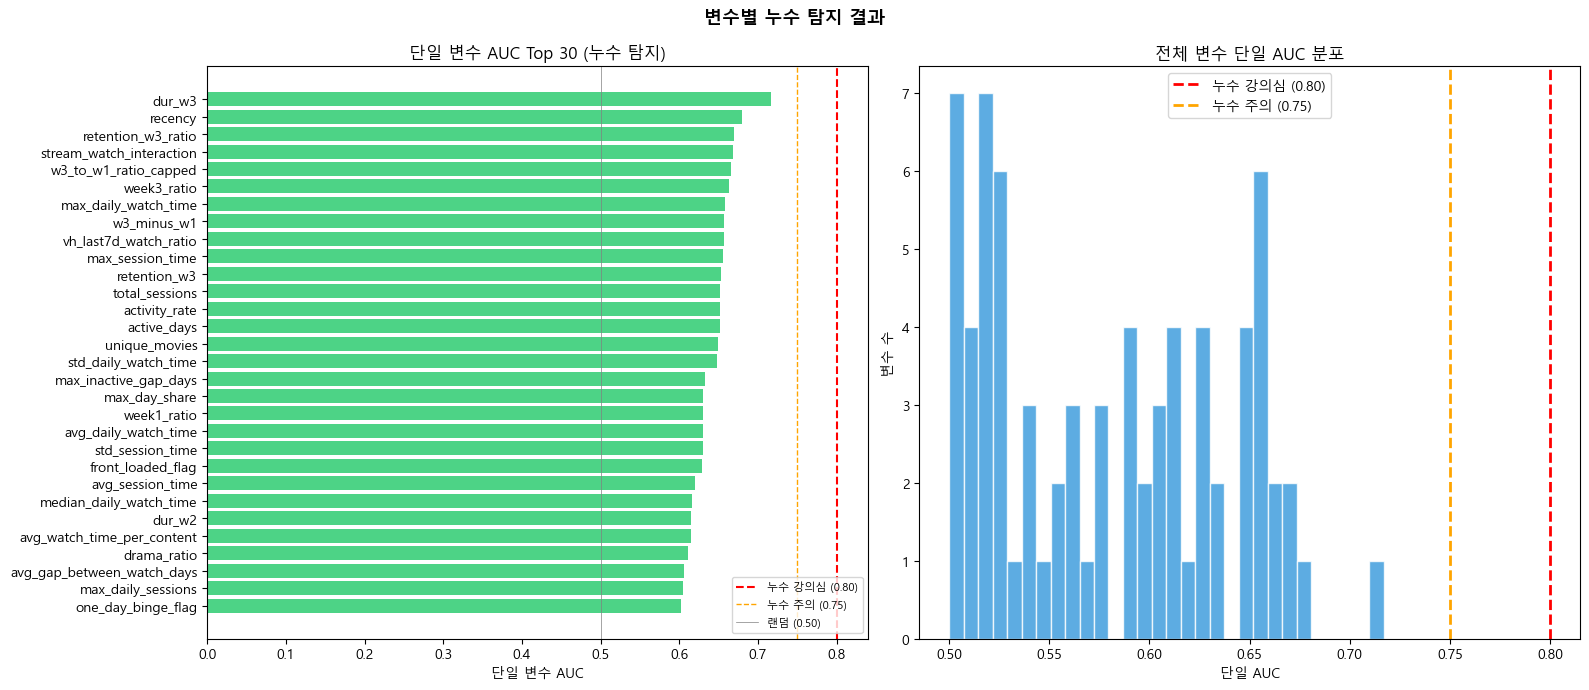

=== 🔴 누수 강의심 변수 ===
없음

=== 🟡 누수 주의 변수 ===
없음


In [13]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ① 단일 AUC Top 30 바 차트
ax = axes[0]
top30 = leak_df.head(30)
colors = ['#e74c3c' if a>=0.80 else ('#f39c12' if a>=0.75 else '#2ecc71')
          for a in top30['단일 AUC']]
ax.barh(top30['변수'][::-1], top30['단일 AUC'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.80, color='red',    linestyle='--', linewidth=1.5, label='누수 강의심 (0.80)')
ax.axvline(0.75, color='orange', linestyle='--', linewidth=1,   label='누수 주의 (0.75)')
ax.axvline(0.50, color='gray',   linestyle='-',  linewidth=0.5, label='랜덤 (0.50)')
ax.set_title('단일 변수 AUC Top 30 (누수 탐지)')
ax.set_xlabel('단일 변수 AUC')
ax.legend(fontsize=8)

# ② AUC 분포 히스토그램
ax = axes[1]
ax.hist(leak_df['단일 AUC'], bins=30, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0.80, color='red',    linestyle='--', linewidth=2, label='누수 강의심 (0.80)')
ax.axvline(0.75, color='orange', linestyle='--', linewidth=2, label='누수 주의 (0.75)')
ax.set_title('전체 변수 단일 AUC 분포')
ax.set_xlabel('단일 AUC')
ax.set_ylabel('변수 수')
ax.legend()

plt.suptitle('변수별 누수 탐지 결과', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 누수 의심 변수만 출력
print('=== 🔴 누수 강의심 변수 ===')
strong = leak_df[leak_df['단일 AUC'] >= 0.80]
if len(strong) > 0:
    print(strong.to_string())
else:
    print('없음')

print('\n=== 🟡 누수 주의 변수 ===')
mild = leak_df[(leak_df['단일 AUC'] >= 0.75) & (leak_df['단일 AUC'] < 0.80)]
if len(mild) > 0:
    print(mild.to_string())
else:
    print('없음')